In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.combine import SMOTEENN


In [2]:
df = pd.read_csv("/content/Loan_Default-1.csv")
df.head()


FileNotFoundError: [Errno 2] No such file or directory: '/content/Loan_Default-1.csv'

**Check missing values**

In [ ]:
df.isnull().sum()


,0
ID,0
year,0
loan_limit,3344
Gender,0
approv_in_adv,908
loan_type,0
loan_purpose,134
Credit_Worthiness,0
open_credit,0
business_or_commercial,0


**Visualize missing values**

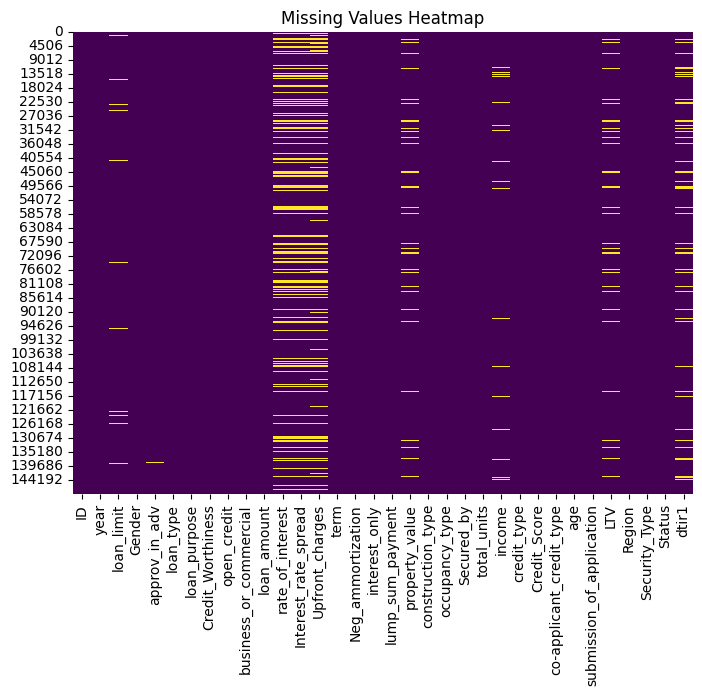

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.isnull(), cbar=False, cmap="coolwarm")
plt.title("Missing Values Heatmap")
plt.show()


In [ ]:
# Fill categorical columns with mode
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numeric columns with median
for col in df.select_dtypes(include=["int64", "float64"]).columns:
    df[col] = df[col].fillna(df[col].median())


**Encode categorical variables**

In [ ]:
cat_cols = df.select_dtypes(include=["object"]).columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


**Check target variable distribution (before balancing)**

/tmp/ipython-input-1234801432.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Status", data=df, palette="Set2")


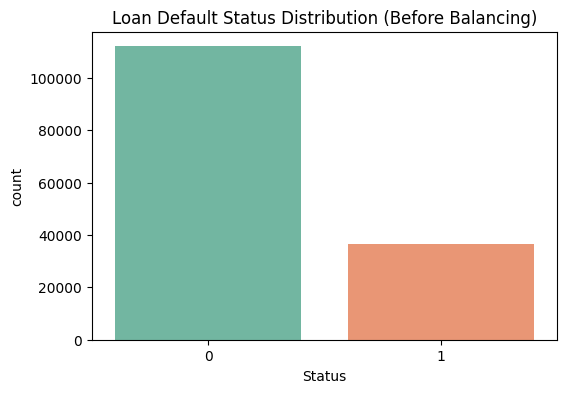

,count
Status,
0,112031
1,36639


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Status", data=df, palette="Set2")
plt.title("Loan Default Status Distribution (Before Balancing)")
plt.show()

df["Status"].value_counts()


**Train-Test Split**

In [ ]:
X = df.drop("Status", axis=1)
y = df["Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


**Scale features**

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


**Balance dataset (SMOTEENN)**

In [ ]:
smote_enn = SMOTEENN(random_state=42)
X_resampled, y_resampled = smote_enn.fit_resample(X_train, y_train)

print("Before balancing:\n", y_train.value_counts())
print("\nAfter balancing:\n", y_resampled.value_counts())


Before balancing:
 Status
0    89625
1    29311
Name: count, dtype: int64

After balancing:
 Status
1    85492
0    66838
Name: count, dtype: int64


**Visualize target distribution after balancing**

/tmp/ipython-input-951294466.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_resampled, palette="Set1")


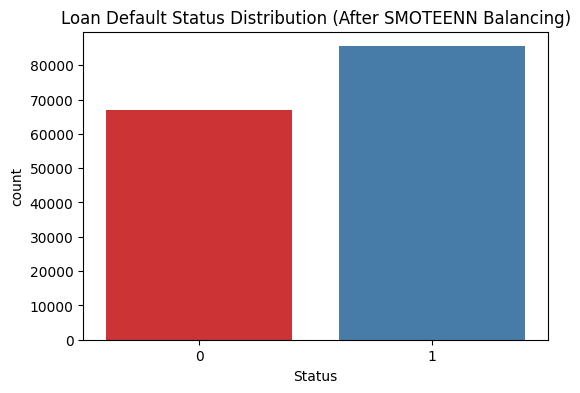

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_resampled, palette="Set1")
plt.title("Loan Default Status Distribution (After SMOTEENN Balancing)")
plt.show()


**Correlation heatmap**

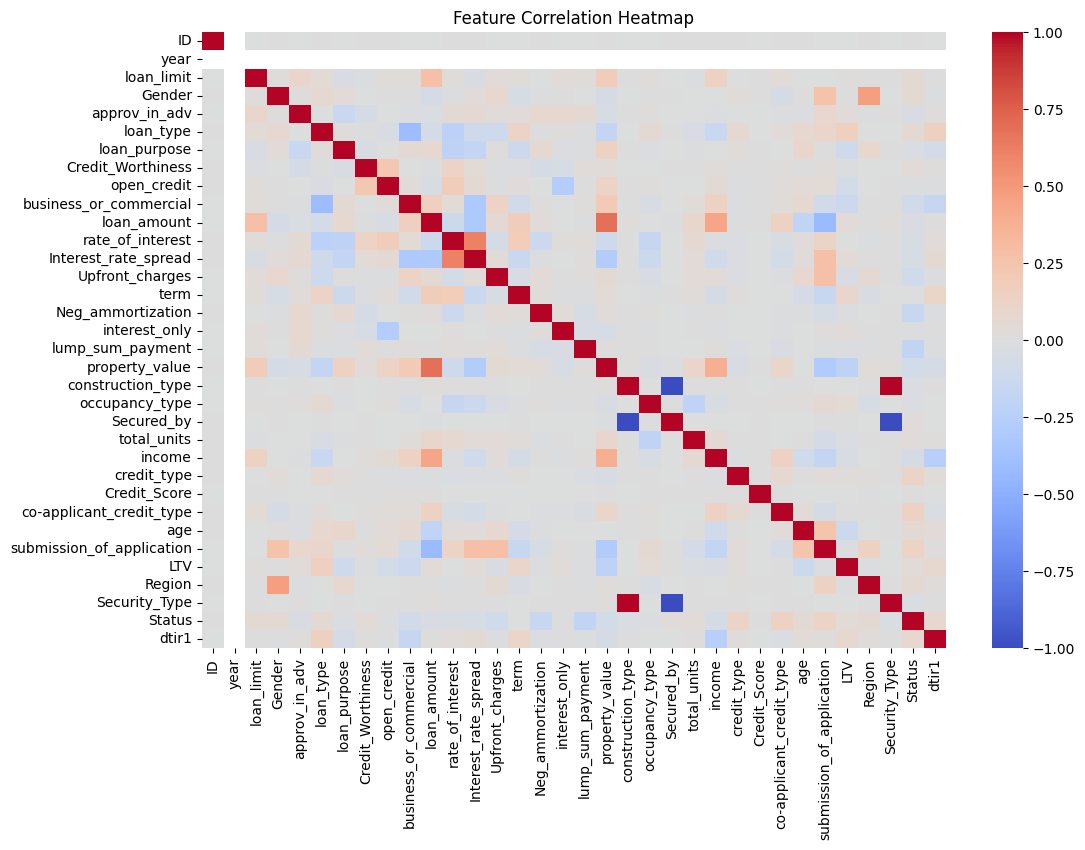

In [ ]:
plt.figure(figsize=(12,8))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


**Distribution of numerical features**

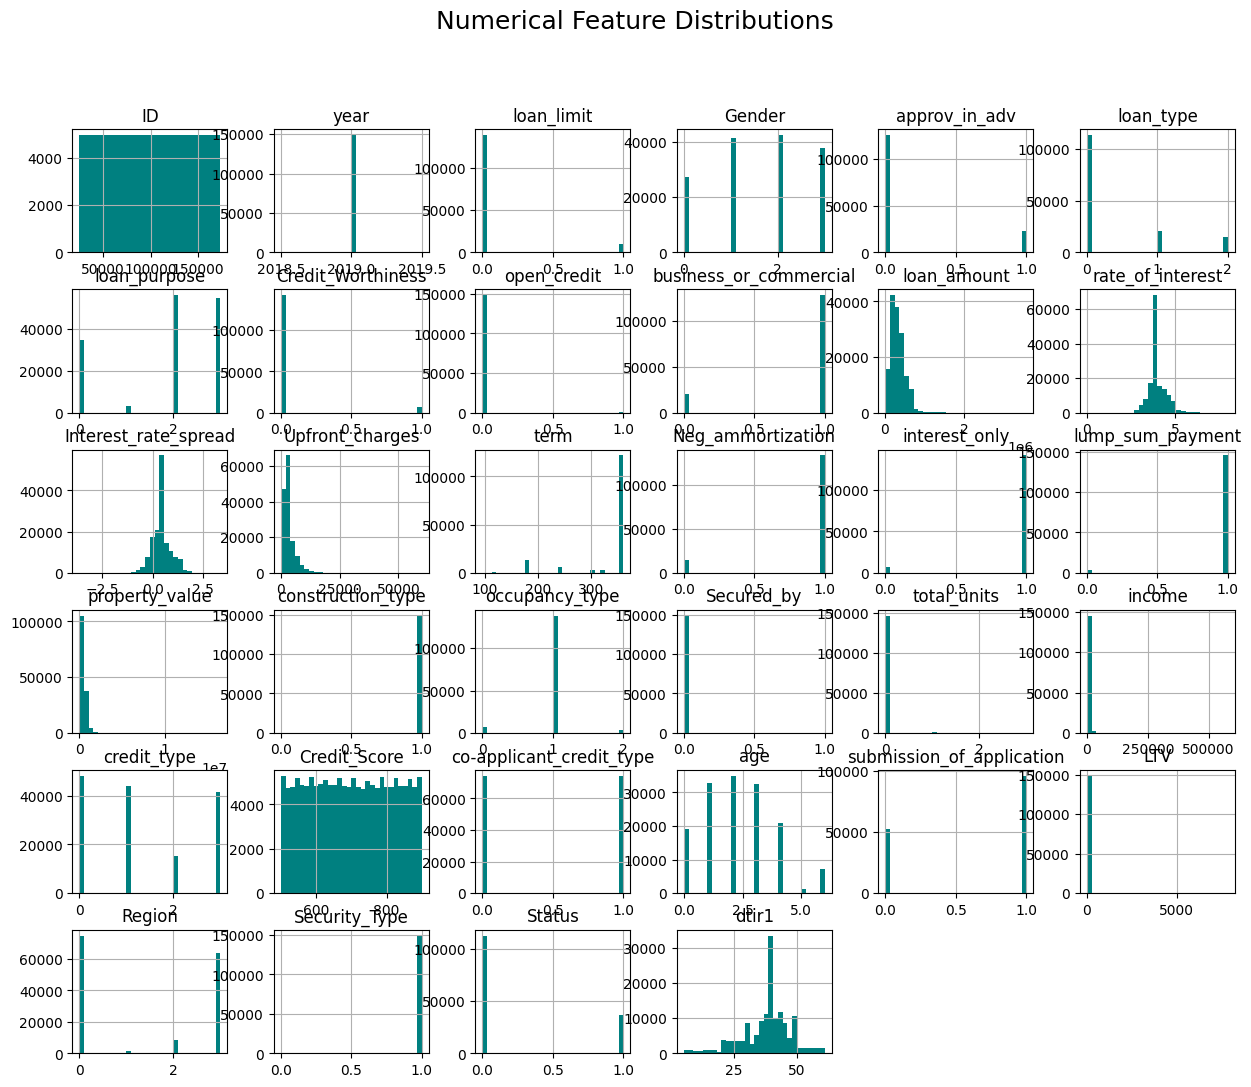

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols].hist(bins=30, figsize=(15,12), color="teal")
plt.suptitle("Numerical Feature Distributions", size=18)
plt.show()


**Boxplots for outlier detection**

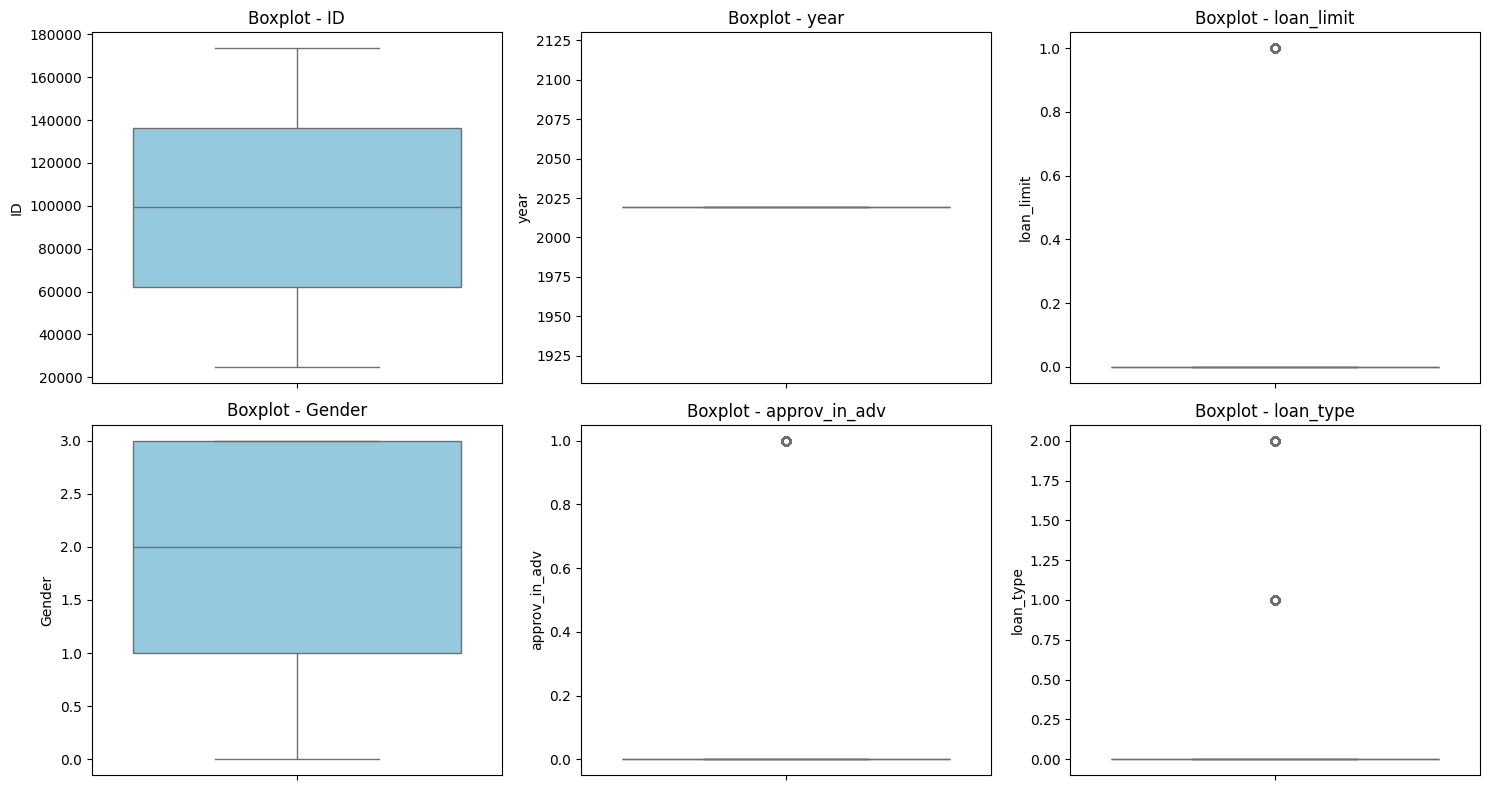

In [ ]:
plt.figure(figsize=(15,8))
for i, col in enumerate(num_cols[:6], 1):   # first 6 numerical features
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(f"Boxplot - {col}")

plt.tight_layout()
plt.show()
